In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [31]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        zoom_range=0.2,
        horizontal_flip=True,
         validation_split=0.2)
training_set = train_datagen.flow_from_directory(
        '../data/chest_xray/train',
        target_size=(224, 224),
        batch_size=32,
        class_mode='binary',
        subset='training')

Found 4173 images belonging to 2 classes.


Test set prep

In [32]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(
        '../data/chest_xray/test',
        target_size=(64, 64),
        batch_size=32,
        class_mode='binary',
        shuffle=False)

Found 624 images belonging to 2 classes.


Validation set prep

In [33]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

validation_set = validation_datagen.flow_from_directory(
    '../data/chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1043 images belonging to 2 classes.


In [34]:
print("Class mapping:", training_set.class_indices)

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [35]:
images, labels = next(training_set)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel range:", images.min(), images.max())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 1.0


BUILDING CNN

In [36]:
cnn=tf.keras.models.Sequential()

In [37]:
cnn.add(tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu',
    input_shape=[224, 224, 3]
))

c:\Users\Srijan Yadav\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
cnn.add(tf.keras.layers.MaxPool2D(
    pool_size=2,
    strides=2
))

In [39]:
cnn.add(tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=3,
    activation='relu'
))

cnn.add(tf.keras.layers.MaxPool2D(
    pool_size=2,
    strides=2
))

In [40]:
cnn.add(tf.keras.layers.Conv2D(
    filters=128,
    kernel_size=3,
    activation='relu'
))

cnn.add(tf.keras.layers.MaxPool2D(
    pool_size=2,
    strides=2
))

In [41]:
cnn.add(tf.keras.layers.GlobalAveragePooling2D())

Dense layer

In [42]:
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [43]:

cnn.add(tf.keras.layers.Dropout(0.5))

cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [44]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

BALANCING

In [46]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(training_set.classes),
    y=training_set.classes
)

class_weights = dict(enumerate(class_weights))

print("Class indices:", training_set.class_indices)
print("Class weights:", class_weights)

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [47]:
history = cnn.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=25,
    class_weight=class_weights
)

Epoch 1/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 70s 527ms/step - accuracy: 0.5794 - loss: 0.6865 - val_accuracy: 0.6098 - val_loss: 0.6912
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 62s 472ms/step - accuracy: 0.6885 - loss: 0.6311 - val_accuracy: 0.6903 - val_loss: 0.6002
Epoch 3/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 479ms/step - accuracy: 0.7386 - loss: 0.5300 - val_accuracy: 0.6328 - val_loss: 0.6167
Epoch 4/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 62s 473ms/step - accuracy: 0.7767 - loss: 0.4688 - val_accuracy: 0.7047 - val_loss: 0.5755
Epoch 5/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 485ms/step - accuracy: 0.8176 - loss: 0.3972 - val_accuracy: 0.8351 - val_loss: 0.4109
Epoch 6/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 489ms/step - accuracy: 0.8335 - loss: 0.3632 - val_accuracy: 0.7459 - val_loss: 0.5260
Epoch 7/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 73s 555ms/step - accuracy: 0.8320 - loss: 0.3676 - val_accuracy: 0.5801 - val_loss: 0.9991
Epoch 8/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 477ms/step - accuracy: 0.8296 - loss: 0

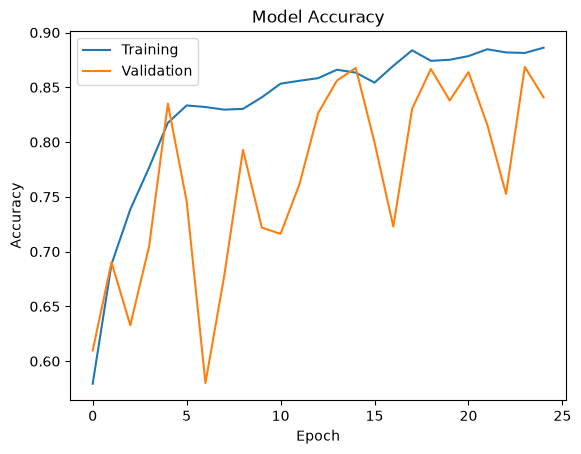

In [48]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training','Validation'])
plt.show()



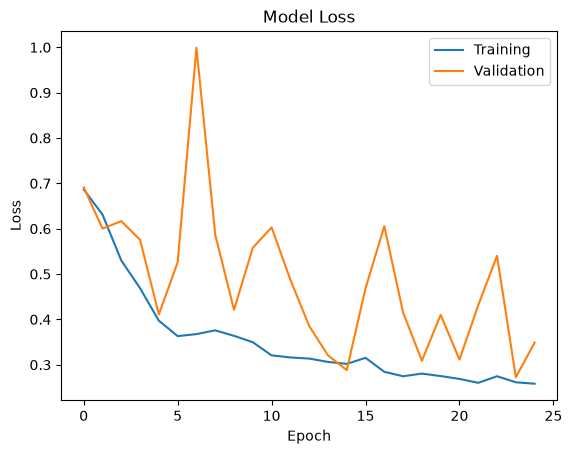

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.show()


In [50]:
test_loss, test_accuracy = cnn.evaluate(test_set)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.6058 - loss: 0.9961
Test Loss: 0.9960730075836182
Test Accuracy: 0.6057692170143127


In [51]:
import numpy as np

test_set.reset()

predictions = cnn.predict(test_set)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_set.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step


In [52]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(true_classes, predicted_classes)
print(cm)

[[203  31]
 [215 175]]


In [53]:
from sklearn.metrics import classification_report
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.49      0.87      0.62       234
   PNEUMONIA       0.85      0.45      0.59       390

    accuracy                           0.61       624
   macro avg       0.67      0.66      0.60       624
weighted avg       0.71      0.61      0.60       624



In [54]:
print(predictions[:20].flatten())

print("Minimum:", predictions.min())
print("Maximum:", predictions.max())
print("Mean:", predictions.mean())

[1.2633109e-03 2.6339120e-01 2.6877460e-05 4.6657177e-04 4.2047875e-04
 3.1558070e-03 7.4858719e-05 2.6444475e-05 6.4741194e-05 1.5809806e-04
 1.3349025e-04 1.0003442e-03 1.3740546e-04 9.8374439e-05 1.0167059e-02
 1.9829818e-04 1.3577756e-01 6.4330765e-05 6.6315712e-05 2.7887163e-06]
Minimum: 3.5911643e-08
Maximum: 0.99990755
Mean: 0.37076873
